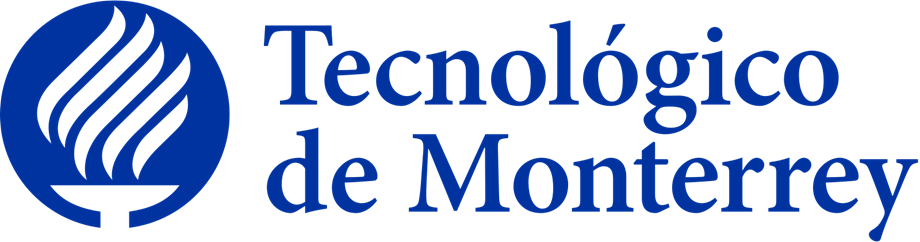


**Instituto Tecnológico y de Estudios Superiores de Monterrey**
**Escuela de Ingeniería y Ciencias**
**Maestría en Inteligencia Artificial Aplicada**

Dra. Grettel Barceló Alonso
Dr. Luis Eduardo Falcón Morales

**Materia Proyecto integrador**

**Avance 4. Modelos alternativos**

Equipo 11

José Gilberto Amaro Aceves - A01794815

Francisco Antonio Enríquez Cabrera - A01795006

Carlos Eduardo García García - A01795206

Fecha: 25-05-2025

## **A. Introducción.**

El objetivo de este avance es la construcción de modelos alternativos en el contexto del cálculo del pronóstico de las exportaciones del tequila, para evaluar su desempeño.

Se consideran 8 modelos desde tres perspectivas: lineales, basados en árboles y basados en distancias. Para cada uno de ellos se calcula su rendimiento, comparándolos y seleccionar a los dos mejores modelos.


## **B. Esquema General del Código**

**1. Definición de modelos**

ESTIMADORES: diccionario con los modelos de regresión a evaluar.

NEEDS_SCALER: indica qué modelos requieren escalado de variables.

**2. Preprocesamiento y selección de variables**

  * asegurar_columna_year(df): garantiza la existencia de una columna de año estándar.

  * ensure_fecha(df): genera una columna Fecha a partir de año y mes.

  * _prep_time_features(df): crea variables estacionales Mes_sin y Mes_cos.

  * seleccionar_features_transformadas(df, objetivo): selecciona columnas transformadas relevantes.

**3. Construcción y guardado de pipelines**

  * make_pipeline(name): construye un Pipeline con selección de variables, escalado y modelo.

  * save_pipeline(pipe, nombre, mae_cv, dataset): guarda el modelo entrenado (.pkl) y sus metadatos (.json).

**4. Evaluación y ajuste de modelos**

  * evaluar_modelos(df, target, ds_name): ejecuta evaluación cruzada con múltiples métricas (MAE, RMSE, R²...).

  * ajustar(top2, X, y, ds): realiza búsqueda de hiperparámetros con RandomizedSearchCV para los dos mejores modelos.

**5. Proyección de valores futuros**

  * proyectar_consolidado_general(file, target, nombre_modelo): entrena un modelo con datos históricos y predice el valor esperado para el año 2040.

  * evaluar_modelo_futuro_pais(df_paises, pais): aplica el mismo proceso para países específicos (por ejemplo, México y EUA).

**6. Visualización de resultados**

  * plot_learning(pipe, X, y, nombre, save_path): curva de aprendizaje (entrenamiento vs validación).

  * plot_importance(pipe, X_df, y_series, cols, nombre, save_path): importancia de variables del modelo final.

  * plot_real_vs_pred_oof(pipe, X, y, nombre, save_path): gráfico Real vs Predicción con validación fuera-de-fold (y guarda la imagen).

**7. Flujo principal**

    7.1 main(): orquesta todo el proceso:

    7.2 Carga y preparación de datos.

    7.3 Evaluación y selección de modelos.

    7.4 Entrenamiento y guardado.

    7.5 Generación de visualizaciones.

    7.6 Proyecciones a futuro por categoría y país.

## **C. Preliminares.**

In [1]:
import os, time, json, warnings
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, mean_absolute_percentage_error, explained_variance_score,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import learning_curve
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.use('Agg')  # Usar backend no interactivo
from sklearn.model_selection import validation_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_predict, TimeSeriesSplit
from sklearn.base import clone
#---
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
#---
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="resource_tracker")


In [2]:
# ──────────────── Rutas ────────────────
# ── Montaje de Google Drive (sólo Colab) y rutas base
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

BASE_PATH   = Path("/content/drive/MyDrive/ProyectoIntegrador/ModeloPronosticos/data")
RESULT_PATH = BASE_PATH.parent / "resultados"
MODEL_PATH  = RESULT_PATH / "models"

# ──────────────── Datasets ─────────────
DATASETS = {
    "Exportaciones Forma":      ("forma_features.csv",      "Valor"),
    "Exportaciones Categoría":  ("categoria_features.csv",  "Valor"),
    "Producción Tequila":       ("produccion_features.csv", "Valor"),
    "Consumo Agave":            ("agave_features.csv",      "Valor"),
    "Exportaciones País":       ("paises_features.csv",     "Total_Pais_Mes"),
}

Mounted at /content/drive


## **D. DESARROLLO DE LOS MODELOS**


### **1. Definición de modelos**


In [3]:
# ──────────────── Utlidades ───────────
def detectar_outliers_iqr(y: pd.Series):
    q1, q3 = np.percentile(y, [25, 75]); iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (y < low) | (y > high)


def asegurar_columna_year(df: pd.DataFrame):
    if "Year" in df.columns: return df
    for col in ["AñoArchivo", "Año", "Anio", "AnioArchivo", "Periodo"]:
        if col in df.columns:
            df["Year"] = df[col]
            return df
    raise ValueError("Sin columna de año equivalente.")

def split_Xy(df: pd.DataFrame, target: str, drop_cols=None):
    drop_cols = drop_cols or []
    y = df[target]
    X = df.drop(columns=[target] + drop_cols, errors="ignore")
    X = X.select_dtypes(include=["number"])
    return X, y

### **2. Preprocesamiento y selección de variables**

**Descripción**

1. En este apartado definimos el diccionario de los modelos regresores.
Se consideran a los modelos


*   **Lineales**: LinearRegression, Ridge y Lasso. La linealidad se asume entre las variables predictoras y la variable objetivo.
*   **Modelos Basados en Árboles**:  DecisionTree, GradientBoosting,HistGradientBoosting, ExtraTrees. Estos modelos no son lineales, y consideraron por ser robustos a valores exremos.
* **Modelos Basados en Distancias**: KNeighbors,SVR (Support Vector Regressor). Estos modelos son no lineales y están basados entre la distancia entre los puntos originales o transaformados del dataset. Son sensibles a la escala de las variables y nocesitan de normalización.

2. Definimos además el diccionario de aquellos modelos que necesitan Escalado y el procesamiento. con el conjunto NEEDS_SCALER.

3. Se establece la selección del tipo de variables que provienen de ser transformadas a partir de las funciones, logaritmo natural, Raíz cuadrada, componentes principales o escalos de tipo min-max. También nos aseguramos
que la variable objetivo no se incluya en el conjunto de predictores.






In [4]:
# ──────────────── Modelos ──────────────
ESTIMADORES = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(random_state=42),
    "Lasso":            Lasso(max_iter=10000, random_state=42),
    "DecisionTree":     DecisionTreeRegressor(random_state=42),
    "KNeighbors":       KNeighborsRegressor(),
    "SVR":              SVR(),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting":   HistGradientBoostingRegressor(random_state=42),
    "ExtraTrees":           ExtraTreesRegressor(n_estimators=200, random_state=42),
}
NEEDS_SCALER = {k: k not in {"DecisionTree", "GradientBoosting","HistGradientBoosting","ExtraTrees"} for k in ESTIMADORES}

# ──────────────── Selección de características ─────
TRANS_PREFIXES = ("Log_", "Sqrt_", "PCA", "_Escalado")

def seleccionar_features_transformadas(df, objetivo):
    cols = [c for c in df.columns if c.startswith(TRANS_PREFIXES) and objetivo not in c]
    return df[cols] if cols else None

### **3. Construcción y guardado de pipelines**

**Descripción:**

Aquí se define la función para el pipeline:


1.   Selección de características
2.   Escalamiento.
3.   Modelo  final [ESTIMADORES]



*   Con este pipeline nos aseguramos de que los pasos del preprocesamiento y modelado sean ejecutados en el orden requerido.
*   La función save_pipeline() guarda el entrenamiento junto con los metadatos,
colocándolo en la carpeta modelos. Se realiza la serialización del modelo, y
los metadatos se guardan en un archivo tipo .json.

Este registro de la metadata sirve para documentar para llevar a cabo
una trazabilidad y replicabilidad de los experimentos.


In [5]:
# ──────────────── Pipeline ────────
def make_pipeline(name):
    steps = [("selector", SelectKBest(f_regression, k="all"))]
    if NEEDS_SCALER[name]:
        steps.append(("scaler", StandardScaler()))
    steps.append(("est", ESTIMADORES[name]))
    return Pipeline(steps)

# ───────────────── Guardado del pipeline + metadatos ─────────────────
def save_pipeline(
    pipe: Pipeline,
    nombre: str,
    mae_cv: float,
    dataset: str,
    *,
    model_dir: Path = RESULT_PATH / "models"
) -> None:
    """
    ▸ Serializa el Pipeline entrenado  →  models/<nombre>.pkl
    ▸ Escribe metadatos reproducibles →  models/<nombre>.json
    """
    model_dir.mkdir(parents=True, exist_ok=True)
    pkl_file  = model_dir / f"{nombre}.pkl"
    meta_file = model_dir / f"{nombre}.json"

    joblib.dump(pipe, pkl_file)

    meta = {
        "dataset":           dataset,
        "modelo":            type(pipe[-1]).__name__,
        "mae_cv":            float(mae_cv),
        "timestamp":         datetime.now().isoformat(timespec="seconds"),
        "sklearn_version":   joblib.__version__,
        "hyperparams":       pipe.get_params(),
        "n_splits":          5,                # o la constante que uses
        "random_state":      42,
    }
    meta_file.write_text(json.dumps(meta, indent=2, default=str))

### **4. Evaluación y ajuste de modelos**

**Descripción:**

1. Se define la función principal para elegir los modelos a partir del conjunto definido previamente. Se crea un dataframe con la variable objetivo, se
realiza el proceso de limpieza y selección de las características, para entrenarlo y hacer una validación de tipo TimeSeriesSplit.

2. Las métricas de sempeño son guardados para cada modelo en un archivo csv.


*   Se filtran los datos para incluir solo observaciones hasta el año 2022 y se eliminan valores atípicos (outliers) usando IQR.

*  Se seleccionan columnas transformadas si están disponibles (Log_, Sqrt_, PCA, etc.).

* Se entrena cada modelo (incluyendo un baseline tipo DummyRegressor) sobre 5 particiones temporales.

* Se calculan múltiples métricas: MAE, RMSE, R2, MedAE, MAPE, Explained Variance.

3. Se define a la función ajustar() para que realice un ajuste a los hiperparámetros de los dos mejores modelos respecto a la métrica MAE, los cuales fueron ya selecciondados. Estos modelos se guardan junto con los hiperparámetros optimizados.

Algunos de los parámtros a ajustar por modelo, son:



*   Ridge: penalización alpha.

* Lasso: penalización alpha en distintos órdenes de magnitud.

* SVR: margen epsilon y penalización C.

* KNeighbors: número de vecinos.

* GradientBoosting: número de árboles y tasa de aprendizaje.

* DecisionTree: profundidad máxima del árbol.


Este paso nos apoya en la sistematización para la comparación de los modelos en su evaluación y considerando distintas métricas. El ajuste de los hiperparámetros es una fase fundamental para optimizar el desempeño de los modelos. La elección de los mejores modelos nos prepara para el siguiente paso sobre la elección del modelo definitivo.



In [6]:
# ──────────────── Evaluar modelos ───────
def evaluar_modelos(df, target, ds_name):
    df = asegurar_columna_year(df)
    df = df[df["Year"] <= 2022].copy().dropna(subset=[target])
    df = df[~detectar_outliers_iqr(df[target])]

    X_t = seleccionar_features_transformadas(df, target)
    if X_t is not None and not X_t.empty:
        X = X_t.copy()
    else:
        X, _ = split_Xy(df, target, drop_cols=["Year_Binned"] if "Year_Binned" in df else None)
    X = X.assign(Year=df["Year"].values)
    y = df[target]

    (RESULT_PATH / "predictores").mkdir(exist_ok=True)
    pd.Series(X.columns).to_csv(RESULT_PATH / f"predictores/{ds_name.replace(' ', '_')}.csv", index=False)

    tscv = TimeSeriesSplit(n_splits=5)
    resultados = []
    for name in ["Dummy"] + list(ESTIMADORES.keys()):
        if name == "Dummy":
            pipe = DummyRegressor(strategy="mean")
        else:
            pipe = make_pipeline(name)
        t0 = time.time(); maes=rmses=r2s=medaes=mapes=expv = []
        maes=[]; rmses=[]; r2s=[]; medaes=[]; mapes=[]; expv=[]
        for tr, ts in tscv.split(X):
            pipe.fit(X.iloc[tr], y.iloc[tr])
            pred = pipe.predict(X.iloc[ts])
            maes.append(mean_absolute_error(y.iloc[ts], pred))
            rmses.append(np.sqrt(mean_squared_error(y.iloc[ts], pred)))
            r2s.append(r2_score(y.iloc[ts], pred))
            medaes.append(median_absolute_error(y.iloc[ts], pred))
            mapes.append(mean_absolute_percentage_error(y.iloc[ts], pred))
            expv.append(explained_variance_score(y.iloc[ts], pred))
        resultados.append({
            "Modelo": name,
            "MAE": np.mean(maes),
            "RMSE": np.mean(rmses),
            "R2": np.mean(r2s),
            "MedAE": np.mean(medaes),
            "MAPE": np.mean(mapes),
            "ExpVar": np.mean(expv),
            "Tiempo": round(time.time()-t0,2)
        })
    df_res = pd.DataFrame(resultados).sort_values("MAE")
    df_res.to_csv(RESULT_PATH / f"comparativa_{ds_name.replace(' ', '_')}.csv", index=False)
    print(f"\n=== {ds_name.upper()} ===\n", df_res.to_string(index=False))
    return df_res, X, y

# ─────────────── Ajuste Top‑2 ───────────
GRID = {
    "Ridge": {"est__alpha": [0.1, 1, 10]},
    "Lasso": {"est__alpha": [1e-3,1e-2,1e-1,1]},
    "DecisionTree": {"est__max_depth": [3,5,10,None]},
    "KNeighbors": {"est__n_neighbors": [3,5,7]},
    "SVR": {"est__C": [0.1,1,10], "est__epsilon": [0.01,0.1]},
    "GradientBoosting": {"est__n_estimators": [100,300], "est__learning_rate": [0.05,0.1]},
    "ExtraTrees": {
    "est__n_estimators": [100, 200, 300],
    "est__max_depth": [None, 5, 10],
    "est__min_samples_split": [2, 5, 10]},
    "HistGradientBoosting": {
    "est__learning_rate": [0.01, 0.05, 0.1],
    "est__max_iter": [100, 200],
    "est__max_depth": [None, 5, 10]}
}

def ajustar(top2, X, y, ds):
    best = {}
    for name in top2:
        if name not in GRID: continue
        search = RandomizedSearchCV(make_pipeline(name), GRID[name], n_iter=20,
                                    scoring="neg_mean_absolute_error", cv=TimeSeriesSplit(5),
                                    n_jobs=1, random_state=42)
        search.fit(X, y)
        best[name] = (search.best_estimator_, -search.best_score_, search.best_params_)
        print(f"{name}: MAE={-search.best_score_:,.2f}  params={search.best_params_}")
    if best:
        pd.DataFrame([{"Modelo":k,"MAE":v[1],**v[2]} for k,v in best.items()])\
          .to_csv(RESULT_PATH / f"best_params_{ds.replace(' ', '_')}.csv", index=False)
    return best

### **5. Proyección de valores futuros**

**Proyección, Evaluación Temporal y Visualización**



1.   Se desarrollan una serie de funciones para el análisis y proyección de las series temporales para los datasets de expotación, consumo y producción
2.   Se asegura la correcta dimensión de la varibale temporal de dataset (ensure_fecha y prep_time_features).
3. Con la función proyectar_consolidado_general se realizan las proyecciones
para el año 2040, considerando los modelos selccionados previamente. Se calculan a nivel categoría y a nivel global.

4. La función evaluar_modelo_futuro hace la estimación por país para focalizarnos en el top 10 de los países con mayor participación.

Con las funciones:


*   plot_learning, se generan las curvas de aprendizaje para valorar la existencia de sobreajuste o subajuste,
*   plot_importance, nos ayuda a identificar las variables con mayor peso del modelo final.
* plot_real_vs_pred_oof, realiza las gráficas de las predicciones versis a los valores reales a lo largo de la variable temporal.







In [7]:
# ─────────────── Proyecciones a 2040 ──────
def ensure_fecha(df):
    if "Fecha" in df.columns:
        return df

    try:
        df = asegurar_columna_year(df.copy())
    except ValueError:
        pass

    posibles_mes = ["Mes", "month", "MONTH"]
    col_mes = next((c for c in posibles_mes if c in df.columns), None)

    posibles_year = ["Year", "Anio", "Año", "year"]
    col_year = next((c for c in posibles_year if c in df.columns), None)

    if col_year is None:
        raise KeyError("No se encontró columna de año para construir 'Fecha'.")

    if col_mes is None:
        df["Mes_tmp"] = 1
        col_mes = "Mes_tmp"

    df["Fecha"] = pd.to_datetime(
        df[col_year].astype(int).astype(str) + "-" +
        df[col_mes].astype(int).astype(str).str.zfill(2) + "-01",
        errors="coerce"
    )

    return df

def _prep_time_features(df):
    df["Mes_sin"] = np.sin(2*np.pi*df["Mes"]/12)
    df["Mes_cos"] = np.cos(2*np.pi*df["Mes"]/12)
    return df

def proyectar_consolidado_general(file, target, nombre_modelo):
    df = pd.read_csv(BASE_PATH / file)
    df = ensure_fecha(df)
    df = df.dropna(subset=["Fecha"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Anio"] = df["Fecha"].dt.year
    df["Mes"]  = df["Fecha"].dt.month
    df = _prep_time_features(df)
    df = df[df["Anio"] <= 2022]

    tipos = df["SubCategoria"].dropna().unique() if "SubCategoria" in df.columns else ["GLOBAL"]
    print(f"\n===== PROYECCIÓN 2040: {nombre_modelo.upper()} =====")
    for tipo in tipos:
        dft = df if tipo == "GLOBAL" else df[df["SubCategoria"]==tipo]
        if dft.shape[0] < 20: continue
        X = dft[["Anio","Mes_sin","Mes_cos"]]; y = dft[target]
        pipe = Pipeline([("sc",StandardScaler()), ("rf", RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))])
        pipe.fit(X, y)
        fut = pd.DataFrame({"Anio":[2040], "Mes":[1]})
        fut = _prep_time_features(fut)
        pred = pipe.predict(fut[["Anio","Mes_sin","Mes_cos"]])[0]
        print(f"{tipo.upper():30s} - {pred:,.2f}")

#---

def evaluar_modelo_futuro_pais(df_paises, pais):
    dfp = df_paises[df_paises["NombrePais"]==pais].copy()
    if dfp.empty: return
    dfp = ensure_fecha(dfp).dropna(subset=["Fecha", "Total_Pais_Mes"])
    dfp["Fecha"] = pd.to_datetime(dfp["Fecha"], errors="coerce")
    dfp["Anio"] = dfp["Fecha"].dt.year; dfp["Mes"] = dfp["Fecha"].dt.month
    dfp = dfp[dfp["Anio"] <= 2022]
    dfp = _prep_time_features(dfp)
    dfp = dfp[~detectar_outliers_iqr(dfp["Total_Pais_Mes"])]
    X = dfp[["Anio","Mes_sin","Mes_cos"]]; y = dfp["Total_Pais_Mes"]
    model = Pipeline([("sc",StandardScaler()),("rf",RandomForestRegressor(n_estimators=200,max_depth=5,random_state=42))])
    model.fit(X,y)
    fut = pd.DataFrame({"Anio":[2040],"Mes":[1]})
    fut = _prep_time_features(fut)
    pred = model.predict(fut[["Anio","Mes_sin","Mes_cos"]])[0]
    print(f"\n Proyección 2040 {pais}: {pred:,.0f} L")

# Curva de aprendizaje MAE
def plot_learning(pipe, X, y, nombre, save_path):
    tscv = TimeSeriesSplit(n_splits=5)
    train_sizes, tr_scores, val_scores = learning_curve(
        pipe, X, y,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        train_sizes=np.linspace(0.2, 1.0, 6),
    )
    tr_mae  = -tr_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    plt.figure(figsize=(6,3))
    plt.plot(train_sizes, tr_mae, "o-", label="Entrenamiento")
    plt.plot(train_sizes, val_mae,  "s-", label="Validación")
    plt.ylabel("MAE"); plt.xlabel("Muestras")
    plt.title(f"Learning curve – {nombre}")
    plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

# Importancia de variables
def plot_importance(pipe, X_df, y_series, cols, nombre, save_path):
    if hasattr(pipe[-1], "feature_importances_"):
        imp = pipe[-1].feature_importances_
        series = pd.Series(imp, index=cols).sort_values(ascending=False)[:20]
    else:
        r = permutation_importance(
            pipe, X_df, y_series,
            n_repeats=10,
            scoring="neg_mean_absolute_error",
            n_jobs=1,
            random_state=42,
        )
        series = pd.Series(r.importances_mean, index=cols).sort_values(ascending=False)[:20]

    plt.figure(figsize=(5,6))
    series[::-1].plot.barh()
    plt.title(f"Top 20 features – {nombre}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

# Real vs Pronosticado
def plot_real_vs_pred_oof(pipe, X, y, nombre, save_path, *, n_splits=5):
    """
    • Calcula predicciones *fuera-de-fold* manualmente con TimeSeriesSplit.
    • Para los puntos que nunca son test (las primeras filas) deja NaN.
    • Guarda la gráfica Real vs. Pred (OOF).
    """
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    y_hat  = np.full_like(y, fill_value=np.nan, dtype=float)

    for tr_idx, ts_idx in tscv.split(X):
        m = clone(pipe)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        y_hat[ts_idx] = m.predict(X.iloc[ts_idx])

    plt.figure(figsize=(8,3))
    plt.plot(y.values,          label="Real",        lw=1.2)
    plt.plot(y_hat,             label="Predicción",  lw=1.2)
    plt.title(f"Real vs. Pred (OOF) – {nombre}")
    plt.xlabel("Observaciones (orden temporal)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    #plt.show()
#---
def plot_real_vs_pred_oof_show(pipe, X, y, nombre, *, n_splits=5, modelo=None, fecha_series=None, ventana_media=7):
    """
    Visualiza valores reales vs predichos (OOF) con estilo tipo serie de tiempo.
    Si se proporciona fecha_series, se usa como eje X; de lo contrario, se usa el índice.
    """
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.base import clone

    plt.style.use("seaborn-v0_8")  # estilo visual limpio
    tscv = TimeSeriesSplit(n_splits=n_splits)
    y_hat = np.full_like(y, fill_value=np.nan, dtype=float)

    for tr_idx, ts_idx in tscv.split(X):
        m = clone(pipe)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        y_hat[ts_idx] = m.predict(X.iloc[ts_idx])

    # Eje X: fechas si están disponibles, sino índice numérico
    x_axis = fecha_series if fecha_series is not None else range(len(y))

    # Convertir a Series para usar rolling
    df_plot = pd.DataFrame({
        "x": x_axis,
        "Real": y.values,
        "Predicción": y_hat
    })

    # Media deslizante
    df_plot["Media_Real"] = df_plot["Real"].rolling(window=ventana_media).mean()
    df_plot["Media_Pred"] = df_plot["Predicción"].rolling(window=ventana_media).mean()

    # Gráfica
    plt.figure(figsize=(14, 5))
    plt.plot(df_plot["x"], df_plot["Real"], label="Real", marker='o', lw=1, markersize=2, alpha=0.6)
    plt.plot(df_plot["x"], df_plot["Predicción"], label="Predicción", marker='o', lw=1, markersize=2, alpha=0.6)
    plt.plot(df_plot["x"], df_plot["Media_Real"], label=f"Media Real ({ventana_media} días)", color="blue", lw=2)
    plt.plot(df_plot["x"], df_plot["Media_Pred"], label=f"Media Pred. ({ventana_media} días)", color="orange", lw=2)

    plt.title(f"Real vs Pred (OOF) – {nombre}" + (f" [{modelo}]" if modelo else ""), fontsize=13)
    plt.xlabel("Fecha" if fecha_series is not None else "Índice temporal")
    plt.ylabel("Valor")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
"""
def plot_real_vs_pred_oof_show(pipe, X, y, nombre, *, n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    y_hat = np.full_like(y, fill_value=np.nan, dtype=float)

    for tr_idx, ts_idx in tscv.split(X):
        m = clone(pipe)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        y_hat[ts_idx] = m.predict(X.iloc[ts_idx])

    plt.figure(figsize=(12, 5))
    plt.plot(y.values, label="Real", lw=1.2)
    plt.plot(y_hat, label="Predicción", lw=1.2)
    plt.title(f"Real vs. Pred (OOF) – {nombre}")
    plt.xlabel("Observaciones (orden temporal)")
    plt.legend()
    plt.tight_layout()
    plt.show()
"""
#---
def plot_comparativa_modelos(df_res, nombre_dataset, save_path):
    """
    Genera y guarda una gráfica consolidada de MAE, R² y MAPE para un conjunto de modelos.

    Parámetros:
    - df_res: DataFrame con columnas ['Modelo', 'MAE', 'R2', 'MAPE'].
    - nombre_dataset: Nombre legible para título (ej. 'Exportaciones Forma').
    - save_path: Ruta del archivo .png donde guardar la imagen.
    """
    df_plot = df_res.sort_values("MAE").copy()
    modelos = df_plot["Modelo"]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # 1. MAE
    axs[0].barh(modelos, df_plot["MAE"], color="skyblue")
    axs[0].set_title("MAE (Error absoluto medio)")
    axs[0].set_xlabel("MAE")
    axs[0].invert_yaxis()
    axs[0].grid(axis='x', linestyle='--', alpha=0.5)

    # 2. R²
    axs[1].barh(modelos, df_plot["R2"], color="lightgreen")
    axs[1].set_title("R² (Varianza explicada)")
    axs[1].set_xlabel("R²")
    axs[1].invert_yaxis()
    axs[1].set_xlim(-2, 1)
    axs[1].grid(axis='x', linestyle='--', alpha=0.5)

    # 3. MAPE
    axs[2].barh(modelos, df_plot["MAPE"] * 100, color="salmon")
    axs[2].set_title("MAPE (%)")
    axs[2].set_xlabel("MAPE (%)")
    axs[2].invert_yaxis()
    axs[2].grid(axis='x', linestyle='--', alpha=0.5)

    plt.suptitle(f"Comparación Consolidada de Modelos – {nombre_dataset}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(save_path, dpi=150)
    plt.show()

### **6. Visualización de resultados**


=== EXPORTACIONES FORMA ===
               Modelo      MAE     RMSE         R2    MedAE     MAPE        ExpVar  Tiempo
          ExtraTrees 1.413638 1.757482  -0.129934 1.187200 0.240057  1.289525e-01    3.24
HistGradientBoosting 1.447567 1.870539  -0.392034 1.123983 0.241098  4.159691e-02    0.82
    GradientBoosting 1.474933 1.933642  -0.665967 1.071412 0.244253 -2.568655e-01    0.69
          KNeighbors 1.540419 1.895553  -0.035803 1.356000 0.282005  2.565735e-01    0.10
        DecisionTree 1.572571 2.037201  -0.789323 1.260000 0.260476 -2.265517e-01    0.06
                 SVR 1.811760 2.258919  -0.632924 1.558232 0.299765  2.278113e-02    0.11
               Lasso 2.032866 2.454748  -1.171145 1.808155 0.301500  1.542882e-01    0.07
               Dummy 2.605924 3.025584  -1.893455 2.410744 0.427317  2.220446e-17    0.03
               Ridge 3.427139 4.061600 -14.394786 4.022218 0.574102 -5.528178e+00    0.10
    LinearRegression 3.441188 4.078065 -14.490778 4.049927 0.575664 -5

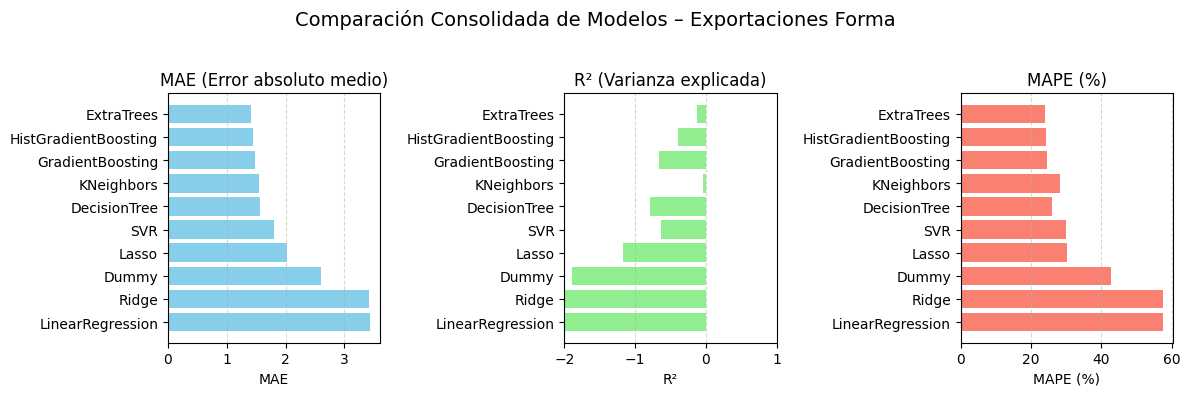

ExtraTrees: MAE=1.39  params={'est__n_estimators': 200, 'est__min_samples_split': 10, 'est__max_depth': 10}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


HistGradientBoosting: MAE=1.43  params={'est__max_iter': 200, 'est__max_depth': 5, 'est__learning_rate': 0.05}
 Modelo final Exportaciones Forma: ExtraTrees  MAE=1.39
→ Mostrando resultados para modelo: ExtraTrees


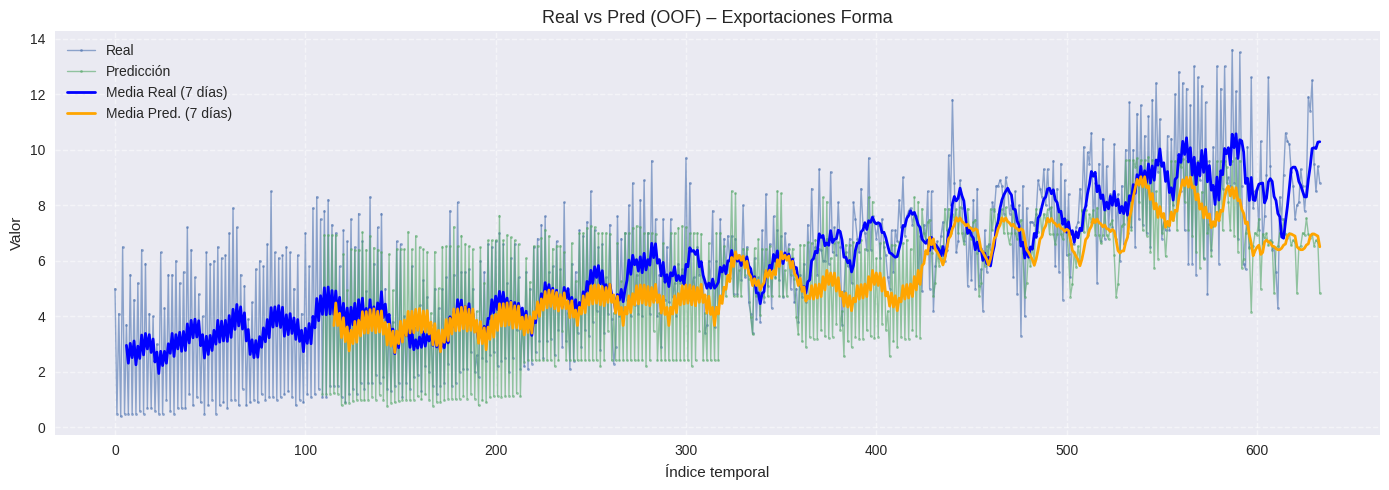


=== EXPORTACIONES CATEGORÍA ===
               Modelo      MAE     RMSE        R2    MedAE     MAPE        ExpVar  Tiempo
          ExtraTrees 1.771388 2.405454 -0.411098 1.307600 0.275574  9.136642e-02    2.55
    GradientBoosting 1.860348 2.506088 -0.499825 1.417728 0.331821  7.234984e-02    0.58
HistGradientBoosting 1.915193 2.584684 -0.517083 1.429627 0.309403  6.385772e-02    0.57
        DecisionTree 2.112661 2.816164 -0.735128 1.540000 0.341175 -5.753246e-02    0.06
          KNeighbors 2.248514 2.746078 -0.200099 2.084000 0.589985  2.346639e-01    0.06
               Lasso 2.382023 2.885257 -0.645588 2.020540 0.384979  3.854472e-01    0.07
                 SVR 2.597569 3.325500 -0.677416 1.865300 0.545554  9.796506e-02    0.11
               Ridge 3.513147 4.143949 -4.079405 3.999583 0.717265 -9.810357e-01    0.08
    LinearRegression 3.522257 4.149681 -4.102640 4.008909 0.716194 -9.901704e-01    0.08
               Dummy 3.541550 4.064689 -1.791904 3.072349 0.822147  4.440892

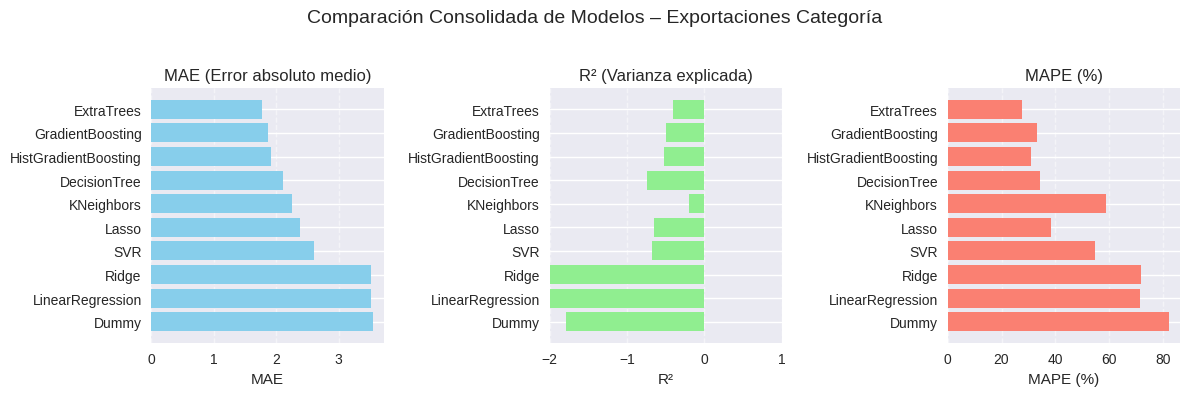

ExtraTrees: MAE=1.74  params={'est__n_estimators': 100, 'est__min_samples_split': 2, 'est__max_depth': 10}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GradientBoosting: MAE=1.82  params={'est__n_estimators': 100, 'est__learning_rate': 0.05}
 Modelo final Exportaciones Categoría: ExtraTrees  MAE=1.74
→ Mostrando resultados para modelo: ExtraTrees


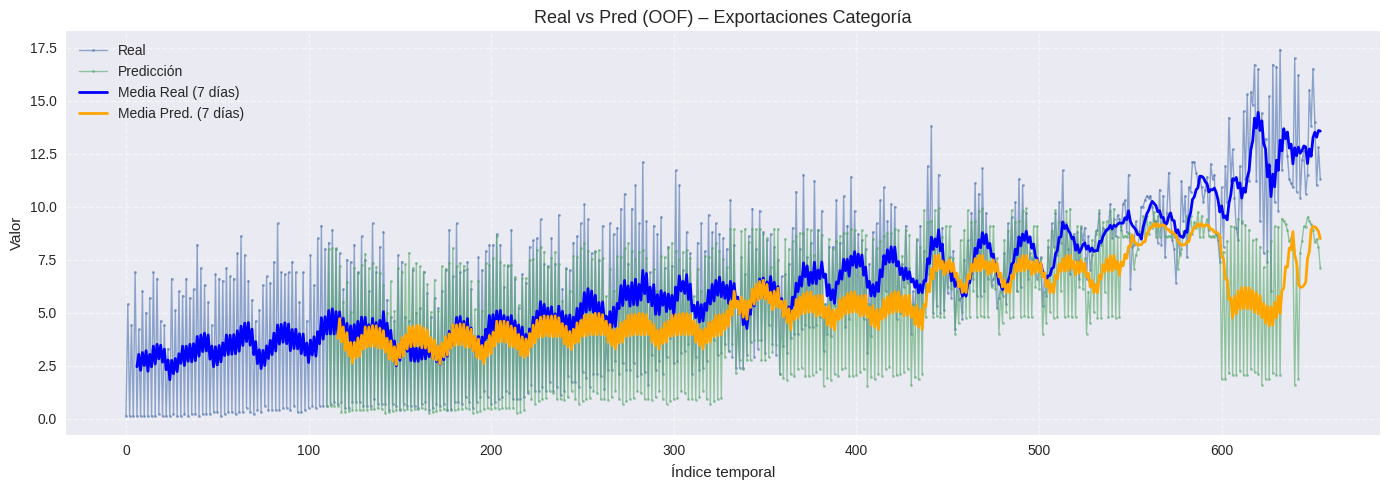


=== PRODUCCIÓN TEQUILA ===
               Modelo      MAE      RMSE         R2     MedAE     MAPE        ExpVar  Tiempo
    GradientBoosting 2.661200  3.440909  -0.101574  2.186914 0.386619  4.555519e-02    0.60
HistGradientBoosting 2.717442  3.421414  -0.134708  2.309660 0.354109  1.207422e-01    0.55
          ExtraTrees 2.936956  3.644377  -0.307315  2.560775 0.367612  7.532077e-02    1.99
          KNeighbors 3.394075  4.036922  -0.478936  3.226000 0.483544  7.025997e-03    0.06
        DecisionTree 3.464340  4.342029  -0.881637  3.120000 0.472773 -5.774962e-01    0.06
                 SVR 3.466325  4.117039  -0.533541  3.111856 0.444425  1.259089e-02    0.11
               Dummy 3.895786  4.568535  -0.944761  3.609538 0.478076  2.220446e-17    0.02
               Lasso 5.474772  6.583398  -8.460762  5.736876 0.608884 -3.300050e+00    0.07
               Ridge 9.386494 11.308455 -34.707710 11.104749 1.191006 -1.165052e+01    0.08
    LinearRegression 9.433702 11.368486 -34.950035 

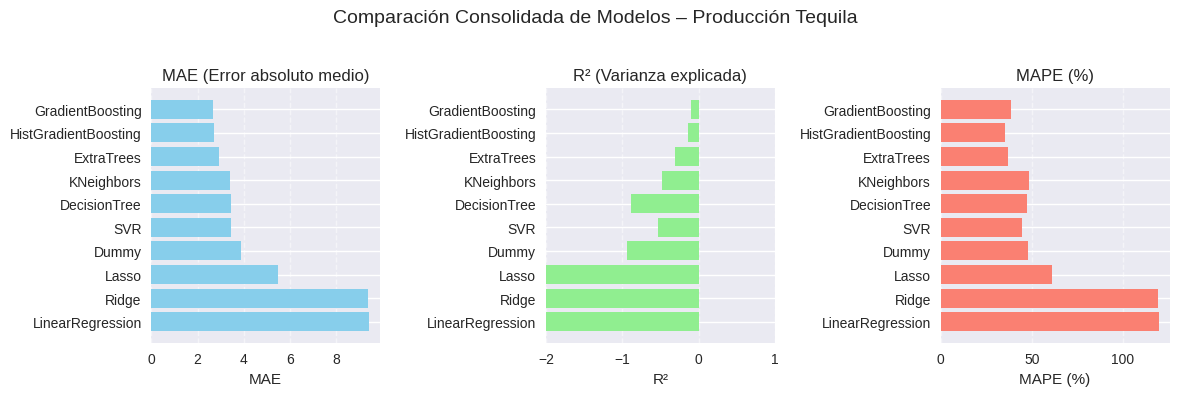

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GradientBoosting: MAE=2.62  params={'est__n_estimators': 300, 'est__learning_rate': 0.05}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


HistGradientBoosting: MAE=2.69  params={'est__max_iter': 200, 'est__max_depth': 10, 'est__learning_rate': 0.05}
 Modelo final Producción Tequila: GradientBoosting  MAE=2.62
→ Mostrando resultados para modelo: GradientBoosting


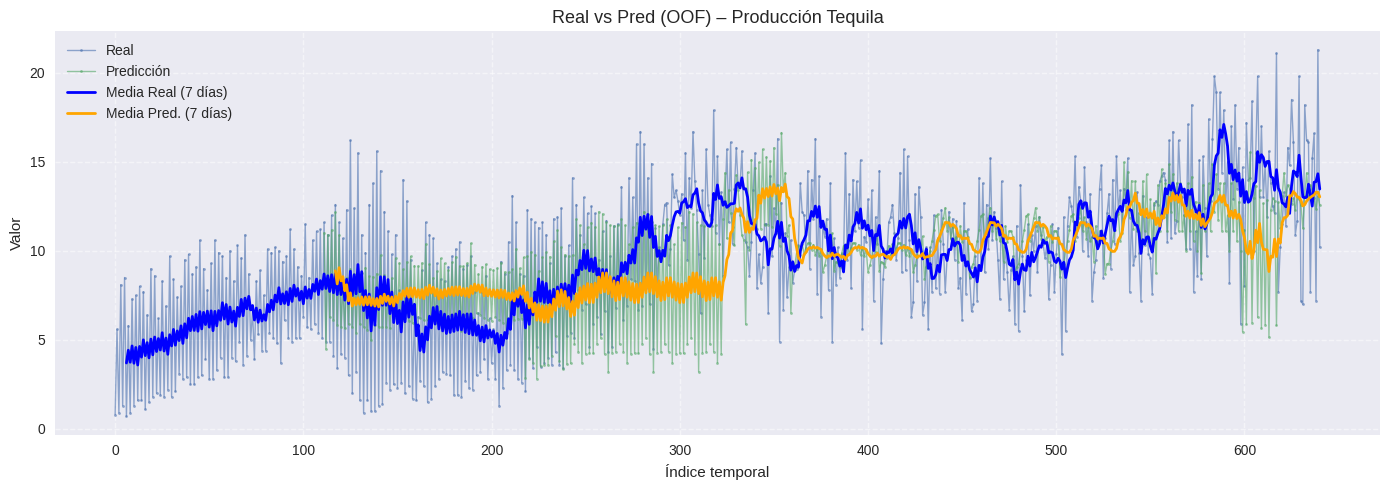


=== CONSUMO AGAVE ===
               Modelo       MAE      RMSE         R2     MedAE     MAPE        ExpVar  Tiempo
    GradientBoosting  8.082041 10.391218   0.227007  6.825814 0.341090  3.681260e-01    0.78
HistGradientBoosting  8.549368 10.824030   0.236944  7.508906 0.346005  4.192050e-01    0.87
          ExtraTrees  8.569028 11.015578   0.141263  7.035200 0.353471  3.318208e-01    2.16
        DecisionTree 10.089903 12.303211   0.041927  8.980000 0.396105  2.194856e-01    0.09
                 SVR 11.716916 15.305676  -0.245564  8.692660 0.358359  1.190233e-01    0.17
          KNeighbors 11.973553 14.750461  -0.388821 10.092000 0.469436  1.521418e-01    0.09
               Dummy 12.368710 16.342400  -0.376360  9.579663 0.366289 -4.440892e-17    0.04
               Lasso 35.157871 44.429294 -17.680491 46.761289 1.158723 -7.515372e+00    0.08
               Ridge 41.580590 50.695464 -18.357421 51.002597 1.610178 -6.758880e+00    0.13
    LinearRegression 41.802834 50.989176 -18.5

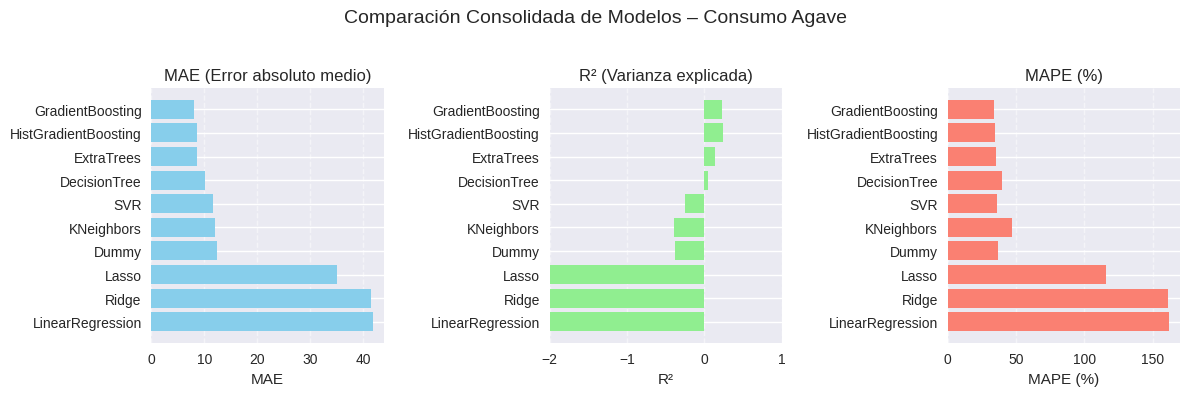

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GradientBoosting: MAE=8.08  params={'est__n_estimators': 100, 'est__learning_rate': 0.1}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


HistGradientBoosting: MAE=8.46  params={'est__max_iter': 200, 'est__max_depth': 10, 'est__learning_rate': 0.1}
 Modelo final Consumo Agave: GradientBoosting  MAE=8.08
→ Mostrando resultados para modelo: GradientBoosting


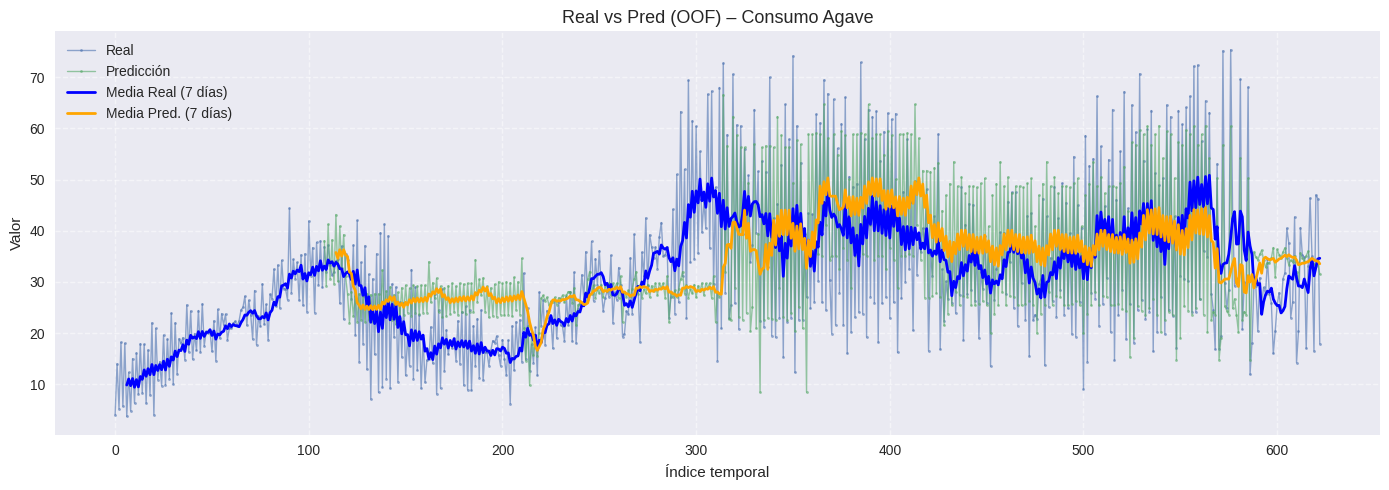

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.019e+10, tolerance: 2.212e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.067e+10, tolerance: 4.477e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.286e+11, tolerance: 6.784e


=== EXPORTACIONES PAÍS ===
               Modelo          MAE         RMSE        R2        MedAE       MAPE        ExpVar  Tiempo
HistGradientBoosting 19363.901172 31492.369192  0.658671  9905.482153  18.863924  6.624238e-01    4.95
          ExtraTrees 20993.889049 34382.899967  0.593825 10305.678060  26.922770  5.949143e-01  149.51
    GradientBoosting 22882.907869 33646.679781  0.601405 14538.392351  23.603403  6.258123e-01   42.55
               Lasso 23082.904113 34285.347981  0.596135 16092.873835  73.454357  5.977716e-01   52.78
    LinearRegression 23083.720221 34285.369819  0.596135 16092.067370  73.458844  5.977725e-01    0.47
               Ridge 23083.947094 34285.411898  0.596134 16092.094770  73.458784  5.977714e-01    0.25
          KNeighbors 23088.990252 35791.682935  0.557462 13588.880400  35.579193  5.711574e-01    8.37
        DecisionTree 28153.895212 47095.552787  0.235679 11486.974000  37.948462  2.497043e-01    3.14
                 SVR 38457.728839 60273.0544

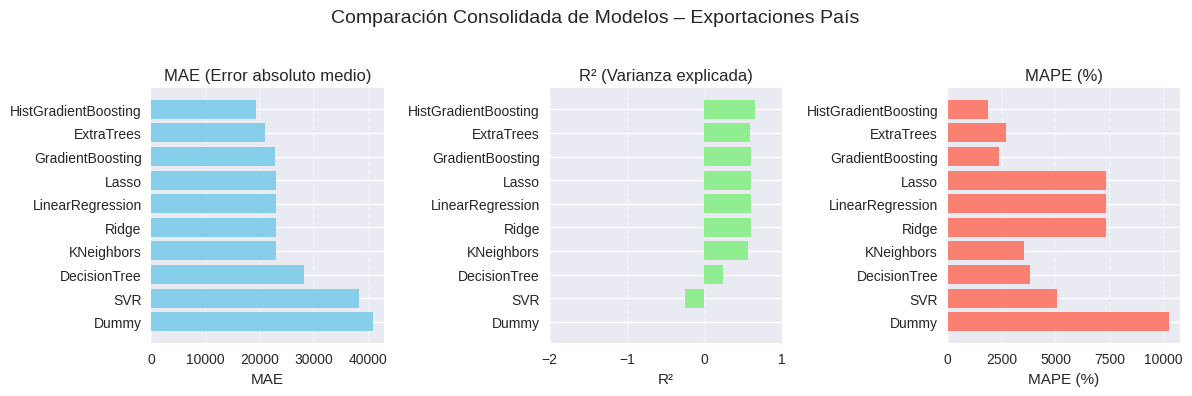

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


HistGradientBoosting: MAE=18,983.46  params={'est__max_iter': 100, 'est__max_depth': None, 'est__learning_rate': 0.05}
ExtraTrees: MAE=19,208.44  params={'est__n_estimators': 200, 'est__min_samples_split': 10, 'est__max_depth': 10}
 Modelo final Exportaciones País: HistGradientBoosting  MAE=18,983.46
→ Mostrando resultados para modelo: HistGradientBoosting


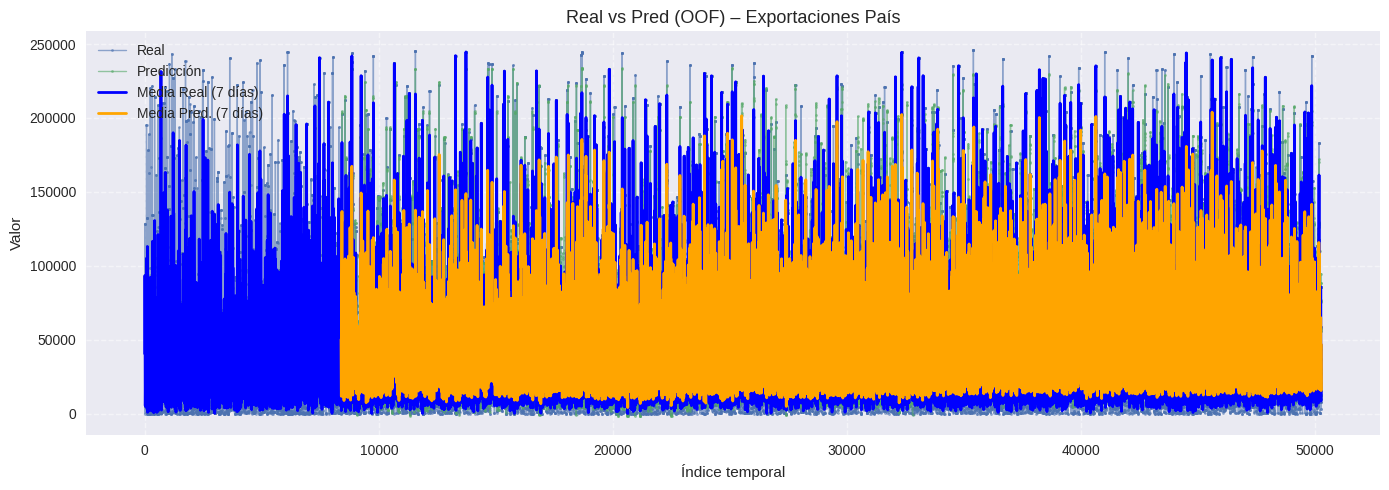


===== PROYECCIÓN 2040: EXPORTACIONES TOTAL FORMA =====
GLOBAL                         - 14.20

===== PROYECCIÓN 2040: EXPORTACIONES TOTAL CATEGORÍA =====
GLOBAL                         - 14.32

===== PROYECCIÓN 2040: PRODUCCIÓN TOTAL TEQUILA =====
GLOBAL                         - 22.65

===== PROYECCIÓN 2040: CONSUMO DE AGAVE TOTAL =====
GLOBAL                         - 99.90

 Proyección 2040 MEXICO: 100,422 L

 Proyección 2040 ESTADOS UNIDOS DE AMERICA: 20,721,329 L


In [8]:
# ─────────────── Main ───────────────
def main():
    for ds_name, (file, target) in DATASETS.items():
        df = pd.read_csv(BASE_PATH / file)

        # ── 1. comparación rápida de los 7 modelos ──────────────────────
        res, X, y = evaluar_modelos(df, target, ds_name)
        #---
        plot_comparativa_modelos(res,nombre_dataset=ds_name, save_path=RESULT_PATH / f"grafico_comparativa_{ds_name.replace(' ', '_').lower()}.png")
        #---
        # ── 2. seleccionar los dos mejores (sin Dummy) ──────────────────
        top2 = res.head(3)["Modelo"].tolist()
        top2 = [m for m in top2 if m != "Dummy"][:2]

        # ── 3. ajuste fino de hiperparámetros ───────────────────────────
        best = ajustar(top2, X, y, ds_name)
        if not best:
            print(f"Sin modelo ajustado para {ds_name}")
            continue

        # ── 4. elegir modelo final con trade-off interpretabilidad ──────
        ridge_mae = best.get("Ridge", (None, np.inf))[1]
        final     = min(best, key=lambda k: best[k][1])

        if final != "Ridge" and ridge_mae < np.inf \
           and (ridge_mae - best[final][1]) / ridge_mae < 0.10:
            final = "Ridge"

        final_pipe = best[final][0]
        final_mae  = best[final][1]
        print(f" Modelo final {ds_name}: {final}  MAE={final_mae:,.2f}")

        modelo_final_pipe = best[final][0]
        mae_final         = best[final][1]

        # ── 5. Graficar y guardar imágenes ──────────────────────────────
        final_pipe.fit(X, y)
#
        print(f"→ Mostrando resultados para modelo: {final}")
        plot_real_vs_pred_oof_show(final_pipe, X, y, nombre=ds_name)
#
        tag = ds_name.replace(" ", "_").lower()

        # 5-a) serializar
        save_pipeline(
            final_pipe,
            nombre  = f"{tag}_{final.lower()}",
            mae_cv  = final_mae,
            dataset = file,
        )

        plot_learning(
            final_pipe, X, y,
            ds_name,
            RESULT_PATH / f"lc_{tag}.png",
        )

        plot_importance(
            final_pipe, X, y,
            X.columns,
            ds_name,
            RESULT_PATH / f"fi_{tag}.png",
        )

        plot_real_vs_pred_oof(
            final_pipe, X, y,
            ds_name,
            RESULT_PATH / f"rvp_oof_{tag}.png",
        )

    # ───────────── 6. Proyecciones consolidadas  ────────────────────────

    #---
    proyectar_consolidado_general("forma_features.csv",      "Valor",
                                  "Exportaciones Total Forma")
    proyectar_consolidado_general("categoria_features.csv",  "Valor",
                                  "Exportaciones Total Categoría")
    proyectar_consolidado_general("produccion_features.csv", "Valor",
                                  "Producción Total Tequila")
    proyectar_consolidado_general("agave_features.csv",      "Valor",
                                  "Consumo de Agave Total")

    # ───────────── 7. Países clave (México y EU) ────────────────────────
    df_paises = pd.read_csv(BASE_PATH / "paises_features.csv")
    evaluar_modelo_futuro_pais(df_paises, "MEXICO")
    evaluar_modelo_futuro_pais(df_paises, "ESTADOS UNIDOS DE AMERICA")

if __name__ == "__main__":
    main()

# Resultados y Conclusiones



1.   El modelo con mayor precisión respecto a la métrica MAE, es *ExtraTrees*, en las **Exportaciones de Forma** con los siguientes resultados

*   MAE = 1.413638. Lo que indica que en promedio hay una diferencia de +/- 1.41 millones de litros por periodo.
*   R² = -0.129934 lo cual en general es una mala metrica para el modelo, sin embargo es el mejor modelo conseguido en esta iteracion del modelo pero en la grafica podemos apreciar que el modelo en general adopta la tendencia y las temporadas de los datos.
* *Sin embargo,* el modelo HistGradientBoosting, también posee métricas
parecidas, esto implica que debemos atender a elegir entre la volocidad de
ejecución o la explicabilidad.

2.   Para el Caso de la **Producción Total de Tequila**, el modelo *GradientBoosting* obtivo:

*   MAE = 2.661200  El error promedio es al rededor a dos millones y medio de litros por periodo.

*   R² = -0.101574. El modelo tiene una capatación del 92% de la varianza observada.

3. El modelo con mejores métricas en **Exportaciones por país** es *HistGradientBoosting*:

*   MAE = 19363.901172. Este desempeño es el que tiene menos control.

*   R² = 0.658671. El modelo no logra captar la variabilidad de exportaciones de manera general pero entre todas las metricas segmentarse por país.


4. El modelo con mejores métricas en **Consumo de agave** es *GradientBoosting*:
*   MAE = 8.082041. Este desempeño es el que tiene menos control.
*   R² = 0.227007. El modelo no logra captar la variabilidad de exportaciones
al segmentarse por país.


## Comentarios adicionales

En general conseguimos implementar varios experimentos con nuevos modelos siendo buena parte de ellos mejor que el baseline.

Ademas, notamos que GradientBoosting es el modelo que mejor desempeño ha tenido en esta serie de experimentos y será un buen lead para el futuro.

Por último, hicimos un par de experimentos los cuales no lograron a llegar a esta implementación como MLPRegressor y ARIMAX, por una parte MLPRegressor tuvo un desempeño muy pesado en procesamiento por lo cual fue descartado. Del lado de ARIMAX se logro un desempeño muy variado y las predicciones a largo plazo fueron insatisfactorios por la cantidad de memorias que tuvieron el mejor "Akaike Information Criterion", además de que el modelo usado de statsmodels regresa el valor predicho despues de la diferencia para remover la estacionalidad lo cual, junto con la complejidad de implementación y mal desempeño se decidió descartar esta opción.





